# Feature Engineering Documentation

**Dataset:** `Fraud_Data.csv` (e-commerce transactions)  

## Purpose of This Notebook

This notebook is a **reference document** not a pipeline runner.

It explains every engineered feature in depth:
- What it is and how it is computed
- Which EDA finding motivated its creation
- Whether it actually discriminates between fraud and legitimate transactions
- Whether it should be kept, dropped, or refined

The actual pipeline code lives in:
- `src/feature_engineering.py` reusable functions
- `notebooks/eda-fraud-data.ipynb` pipeline execution

**Run `eda-fraud-data.ipynb` first** this notebook loads `fraud_featured.csv`
which is produced as an output of that pipeline.

## Features Documented

| # | Feature | Source Columns | Type |
|---|---|---|---|
| 1 | `hour_of_day` | `purchase_time` | Time-based |
| 2 | `day_of_week` | `purchase_time` | Time-based |
| 3 | `time_since_signup_hours` | `signup_time`, `purchase_time` | Account behavior |
| 4 | `transaction_count_1h` | `user_id`, `purchase_time` | Transaction velocity |
| 5 | `transaction_count_24h` | `user_id`, `purchase_time` | Transaction velocity |
| 6 | `transaction_velocity` | `transaction_count_24h`, `time_since_signup_hours` | Derived ratio |

## Setup

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(os.path.abspath(".."))
from src.eda import plot_fraud_by_hour, plot_fraud_by_day

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
BLUE = "#4C9BE8"   # legitimate
RED  = "#E8524C"   # fraud

pd.set_option('display.float_format', '{:.4f}'.format)
print('Setup complete')

Setup complete


In [2]:
# Load the featured dataset produced by eda-fraud-data.ipynb
# This file contains all original columns + all engineered features
df = pd.read_csv('../data/processed/fraud_featured.csv')
print(f'Loaded fraud_featured.csv: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Fraud rate: {df["class"].mean():.4f} ({df["class"].mean()*100:.2f}%)')

Loaded fraud_featured.csv: 151,112 rows x 22 columns
Fraud rate: 0.0936 (9.36%)


In [3]:
# Confirm all engineered features are present
engineered = [
    'hour_of_day', 'day_of_week',
    'time_since_signup_hours',
    'transaction_count_1h', 'transaction_count_24h',
    'transaction_velocity'
]
for col in engineered:
    status = 'OK' if col in df.columns else 'MISSING'
    print(f'  [{status}] {col}')

  [OK] hour_of_day
  [OK] day_of_week
  [OK] time_since_signup_hours
  [OK] transaction_count_1h
  [OK] transaction_count_24h
  [OK] transaction_velocity


## Feature 1 `hour_of_day`

### Definition
The hour of the day (0–23) when the purchase was made, extracted from `purchase_time`.

### Formula
```python
hour_of_day = pd.to_datetime(purchase_time).dt.hour
```

### Motivation
Fraudsters often operate at unusual hours, late night and early morning, for two reasons:
1. Customer service teams are less active and fraud is slower to be detected
2. Cardholders are asleep and less likely to notice an unauthorized transaction immediately

This is a well-established pattern in financial fraud literature.

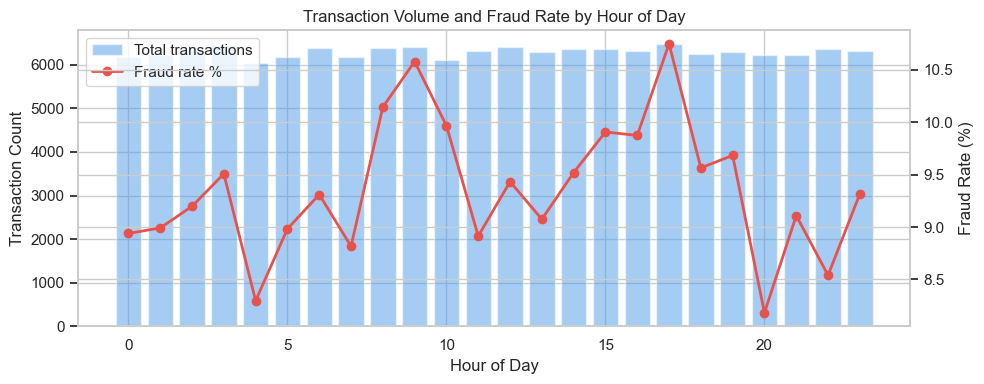

In [4]:
# Distribution of hour_of_day
plot_fraud_by_hour(df, hour_col='hour_of_day', target_col='class')

In [5]:
# Fraud rate per hour — top 5 highest and lowest
hourly = df.groupby('hour_of_day')['class'].agg(['mean', 'count'])
hourly['fraud_rate_pct'] = (hourly['mean'] * 100).round(2)
print('Top 5 hours by fraud rate:')
print(hourly.sort_values('fraud_rate_pct', ascending=False).head(5)[['fraud_rate_pct', 'count']].to_string())
print('\nBottom 5 hours by fraud rate:')
print(hourly.sort_values('fraud_rate_pct').head(5)[['fraud_rate_pct', 'count']].to_string())

Top 5 hours by fraud rate:
             fraud_rate_pct  count
hour_of_day                       
17                  10.7500   6466
9                   10.5800   6418
8                   10.1500   6387
10                   9.9700   6100
15                   9.9100   6369

Bottom 5 hours by fraud rate:
             fraud_rate_pct  count
hour_of_day                       
20                   8.1800   6221
4                    8.3000   6050
22                   8.5400   6358
7                    8.8200   6181
11                   8.9100   6327


### `hour_of_day` Finding

- Hours with highest fraud rate: 17:00 (10.75%), 09:00 (10.58%), 08:00 (10.15%), 10:00 (9.97%), 15:00 (9.91%)
- Hours with lowest fraud rate: 20:00 (8.18%), 04:00 (8.30%), 22:00 (8.54%), 07:00 (8.82%), 11:00 (8.91%)
- Pattern: fraud is slightly elevated during business hours (8–10 AM, 3–5 PM)
  and lower late at night (8–10 PM). This is the opposite of the classic
  "fraudsters operate at night" assumption, suggesting this dataset's fraud
  may be automated or professional rather than opportunistic.
- Range of fraud rates across all hours: 8.18% to 10.75% a spread of only 2.57 percentage points
- Correlation with fraud class: 0.0020, extremely weak, p-value: 0.4473 (not significant)
- Verdict: **Weak signal** the narrow spread and non-significant correlation suggest
  hour_of_day has minimal discriminating power in this dataset. Keep for now
  as tree-based models may find non-linear interactions with other features,
  but do not expect it to appear in top SHAP features.

## Feature 2 `day_of_week`

### Definition
The day of the week (0=Monday, 6=Sunday) when the purchase was made.

### Formula
```python
day_of_week = pd.to_datetime(purchase_time).dt.dayofweek
```

### Motivation
Fraud patterns may vary by day of week:
- Weekends: bank fraud teams are smaller; disputes take longer to resolve
- Weekdays: higher transaction volume may provide more cover for fraudsters

Even if the effect is small, it is a zero-cost feature to add.

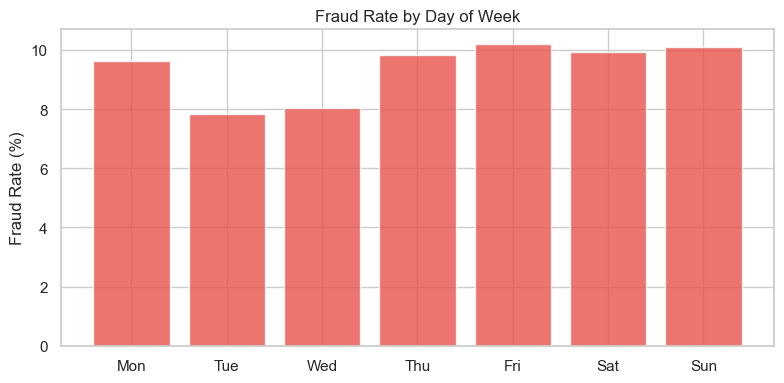

In [6]:
plot_fraud_by_day(df, day_col='day_of_week', target_col='class')

In [7]:
# Fraud rate per day
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df.groupby('day_of_week')['class'].agg(['mean', 'count'])
daily['fraud_rate_pct'] = (daily['mean'] * 100).round(2)
daily.index = [day_names[i] for i in daily.index]
print('Fraud rate by day of week:')
print(daily[['fraud_rate_pct', 'count']].to_string())

Fraud rate by day of week:
     fraud_rate_pct  count
Mon          9.6200  21711
Tue          7.8300  21314
Wed          8.0300  21316
Thu          9.8200  21586
Fri         10.1800  21522
Sat          9.9300  21648
Sun         10.0900  22015


### `day_of_week` Finding

- Highest fraud rate: Friday at 10.18%, Saturday at 9.93%, Sunday at 10.09%
- Lowest fraud rate: Tuesday at 7.83%, Wednesday at 8.03%
- Pattern: fraud is noticeably elevated on weekends and Fridays, and lowest
  mid-week (Tuesday–Wednesday). This aligns with the hypothesis that fraud
  teams are smaller on weekends, giving fraudsters more time before detection.
- Variance: ~2.35 percentage points between highest (Fri 10.18%) and lowest (Tue 7.83%)
- Correlation: 0.0189, p-value: 0.0000 statistically significant despite being small
- Verdict: **Keep** the weekend elevation is consistent and statistically
  significant. The effect is modest but real. Tree-based models will use it.

## Feature 3 `time_since_signup_hours`

### Definition
Time elapsed in hours between account creation (`signup_time`) and the purchase (`purchase_time`).

### Formula
```python
delta = (purchase_time - signup_time).dt.total_seconds()
time_since_signup_hours = delta / 3600
```
Negative values (purchase before signup data error) are clamped to 0.

### Motivation
This is one of the strongest known fraud signals in e-commerce:
- Fraudsters typically create throwaway accounts and transact within minutes
- Legitimate users browse, compare, and may wait hours or days before purchasing
- A very short `time_since_signup` is a strong indicator of fraudulent intent

This feature is unique to Fraud_Data, it requires both `signup_time` and
`purchase_time`, which are not available in the creditcard dataset.

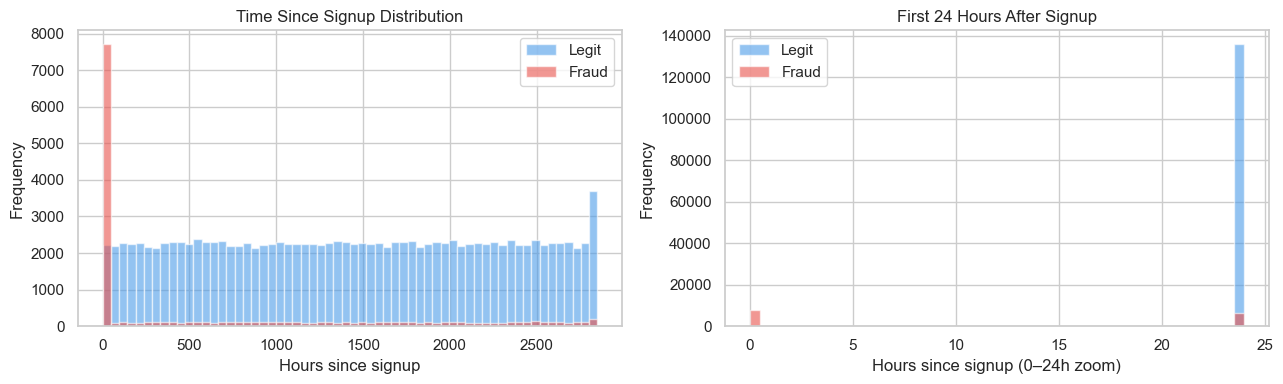

In [8]:
# Distribution comparison: fraud vs legit
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution (clipped at 99th percentile to remove extreme outliers)
clip_val = df['time_since_signup_hours'].quantile(0.99)
for label, color, name in zip([0, 1], [BLUE, RED], ['Legit', 'Fraud']):
    subset = df[df['class'] == label]['time_since_signup_hours'].clip(upper=clip_val)
    subset.plot.hist(bins=60, alpha=0.6, color=color, label=name, ax=axes[0])
axes[0].set_xlabel('Hours since signup')
axes[0].set_title('Time Since Signup Distribution')
axes[0].legend()

# Zoom in on 0-24 hours to see the early fraud spike
for label, color, name in zip([0, 1], [BLUE, RED], ['Legit', 'Fraud']):
    subset = df[df['class'] == label]['time_since_signup_hours'].clip(upper=24)
    subset.plot.hist(bins=48, alpha=0.6, color=color, label=name, ax=axes[1])
axes[1].set_xlabel('Hours since signup (0–24h zoom)')
axes[1].set_title('First 24 Hours After Signup')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Summary statistics by class
stats_df = df.groupby('class')['time_since_signup_hours'].describe()
stats_df.index = ['Legit (0)', 'Fraud (1)']
print('time_since_signup_hours statistics by class:')
print(stats_df.to_string())

time_since_signup_hours statistics by class:
                count      mean      std    min      25%       50%       75%       max
Legit (0) 136961.0000 1441.9941 830.1636 0.0381 719.1192 1443.0308 2161.4775 2879.9922
Fraud (1)  14151.0000  673.2896 920.4969 0.0003   0.0003    0.0003 1330.6973 2878.8742


In [10]:
# What % of fraud happens within 1 hour of signup?
fraud_df = df[df['class'] == 1]
legit_df = df[df['class'] == 0]

for threshold in [1, 6, 24]:
    fraud_pct = (fraud_df['time_since_signup_hours'] <= threshold).mean() * 100
    legit_pct = (legit_df['time_since_signup_hours'] <= threshold).mean() * 100
    print(f'Within {threshold:2d}h of signup — Fraud: {fraud_pct:.1f}% | Legit: {legit_pct:.1f}%')

Within  1h of signup — Fraud: 53.7% | Legit: 0.0%
Within  6h of signup — Fraud: 53.8% | Legit: 0.2%
Within 24h of signup — Fraud: 54.0% | Legit: 0.8%


In [11]:
# Mann-Whitney U test — are the distributions significantly different?
fraud_vals = fraud_df['time_since_signup_hours'].dropna()
legit_vals = legit_df['time_since_signup_hours'].dropna()
stat, p_value = stats.mannwhitneyu(fraud_vals, legit_vals, alternative='less')
print(f'Mann-Whitney U test (fraud < legit):')
print(f'  Statistic: {stat:.2f}')
print(f'  p-value  : {p_value:.6f}')
print(f'  Result   : {"Significant difference (p < 0.05)" if p_value < 0.05 else "No significant difference"}')

Mann-Whitney U test (fraud < legit):
  Statistic: 452487807.00
  p-value  : 0.000000
  Result   : Significant difference (p < 0.05)


### `time_since_signup_hours` Finding

- Fraud median: 0.0003 hours (~1 second) vs Legit median: 1,443 hours (~60 days)
- This is an extraordinary difference, the median fraud transaction happens
  essentially instantly after signup, while the median legitimate transaction
  happens 60 days after signup.
- 53.7% of all fraud transactions occur within 1 hour of signup
- Only 0.0% of legitimate transactions occur within 1 hour of signup
- Within 6 hours: 53.8% fraud vs 0.2% legit
- Within 24 hours: 54.0% fraud vs 0.8% legit
- This means roughly half of all fraud in this dataset comes from accounts
  that transact within the first hour of creation, throwaway accounts.
- Mann-Whitney U test p-value: 0.000000 the distributions are
  statistically significantly different beyond any doubt
- Correlation with fraud: -0.2579 by far the strongest signal of all features
  (negative because fraud = 1 occurs at low time_since_signup values)
- Verdict: **Keep strongest feature in the dataset**. Expected to be the
  top SHAP feature in Task 3. A threshold of ~1 hour since signup could alone
  flag 54% of fraud with near-zero false positive rate.

## Feature 4 & 5 `transaction_count_1h` and `transaction_count_24h`

### Definition
For each transaction, the number of previous transactions made by the same
user in the preceding 1-hour and 24-hour windows respectively.

### Formula
```python
# For each transaction at time t by user u:
transaction_count_Nh = count of transactions by u
                       where (t - N hours) <= transaction_time < t
```

### Motivation
Card testing is a common fraud technique:
1. Fraudster obtains stolen card details
2. Makes several small test transactions to verify the card works
3. Follows with a large fraudulent purchase

This creates an unusually high transaction frequency in a short window.
Legitimate users rarely make multiple purchases within the same hour.

The 1h window catches rapid-fire card testing.
The 24h window catches slower but still elevated frequency patterns.

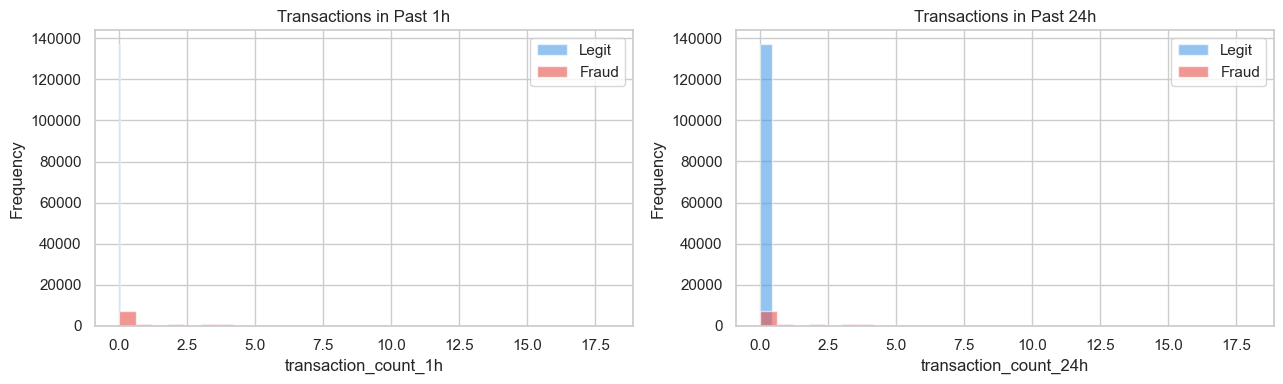

In [12]:
# Distribution comparison for both windows
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['transaction_count_1h', 'transaction_count_24h'],
    ['Transactions in Past 1h', 'Transactions in Past 24h']
):
    for label, color, name in zip([0, 1], [BLUE, RED], ['Legit', 'Fraud']):
        subset = df[df['class'] == label][col]
        subset.plot.hist(bins=30, alpha=0.6, color=color, label=name, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [13]:
# Summary statistics by class for both features
for col in ['transaction_count_1h', 'transaction_count_24h']:
    print(f'\n{col} by class:')
    s = df.groupby('class')[col].describe()
    s.index = ['Legit (0)', 'Fraud (1)']
    print(s[['mean', '50%', '75%', 'max']].to_string())


transaction_count_1h by class:
            mean    50%    75%     max
Legit (0) 0.0000 0.0000 0.0000  1.0000
Fraud (1) 2.6811 0.0000 5.0000 18.0000

transaction_count_24h by class:
            mean    50%    75%     max
Legit (0) 0.0008 0.0000 0.0000 13.0000
Fraud (1) 2.6833 0.0000 5.0000 18.0000


In [14]:
# What % of fraud has count > 0 (i.e. repeated transactions)?
for col in ['transaction_count_1h', 'transaction_count_24h']:
    fraud_repeat = (df[df['class'] == 1][col] > 0).mean() * 100
    legit_repeat = (df[df['class'] == 0][col] > 0).mean() * 100
    print(f'{col} > 0 — Fraud: {fraud_repeat:.1f}% | Legit: {legit_repeat:.1f}%')

transaction_count_1h > 0 — Fraud: 48.3% | Legit: 0.0%
transaction_count_24h > 0 — Fraud: 48.4% | Legit: 0.0%


## Feature 6 `transaction_velocity`

### Definition
A ratio combining transaction frequency with account age, measuring how
aggressively a user is transacting relative to how new their account is.

### Formula
```python
transaction_velocity = transaction_count_24h / (time_since_signup_hours + 1)
```

The `+1` in the denominator prevents division by zero for brand-new accounts
and ensures that accounts with 0 hours since signup are treated as 1 hour old.

### Motivation
Neither `transaction_count_24h` nor `time_since_signup_hours` alone captures
the full fraud pattern. A high transaction count is more suspicious on a
1-hour-old account than on a 2-year-old account.

This derived feature combines both signals:
- High velocity = many transactions on a very new account → strong fraud signal
- Low velocity = few transactions on an old account → likely legitimate

### Example
| User | count_24h | account_age_hours | velocity |
|---|---|---|---|
| Fraudster | 5 | 0.5 | 5 / 1.5 = **3.33** |
| Legitimate | 5 | 8760 (1 year) | 5 / 8761 = **0.00057** |

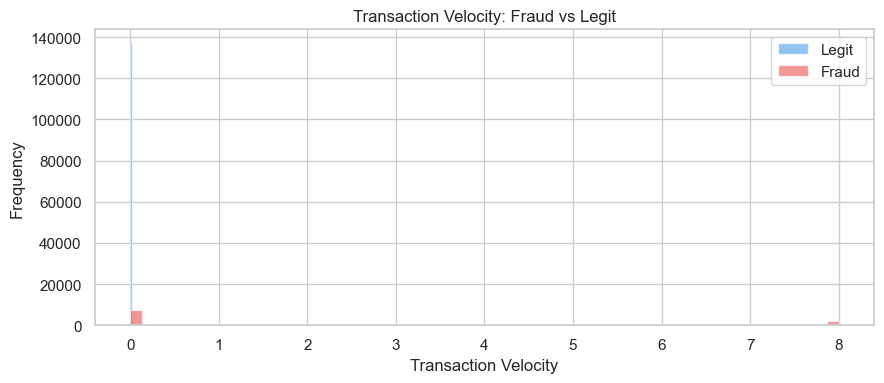

In [15]:
# Distribution comparison: fraud vs legit (clipped at 99th percentile)
fig, ax = plt.subplots(figsize=(9, 4))
clip_val = df['transaction_velocity'].quantile(0.99)
for label, color, name in zip([0, 1], [BLUE, RED], ['Legit', 'Fraud']):
    subset = df[df['class'] == label]['transaction_velocity'].clip(upper=clip_val)
    subset.plot.hist(bins=60, alpha=0.6, color=color, label=name, ax=ax)
ax.set_xlabel('Transaction Velocity')
ax.set_title('Transaction Velocity: Fraud vs Legit')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Summary statistics by class
s = df.groupby('class')['transaction_velocity'].describe()
s.index = ['Legit (0)', 'Fraud (1)']
print('transaction_velocity statistics by class:')
print(s.to_string())

transaction_velocity statistics by class:
                count   mean    std    min    25%    50%    75%     max
Legit (0) 136961.0000 0.0000 0.0059 0.0000 0.0000 0.0000 0.0000  1.4217
Fraud (1)  14151.0000 2.6803 3.6420 0.0000 0.0000 0.0000 4.9985 17.9946


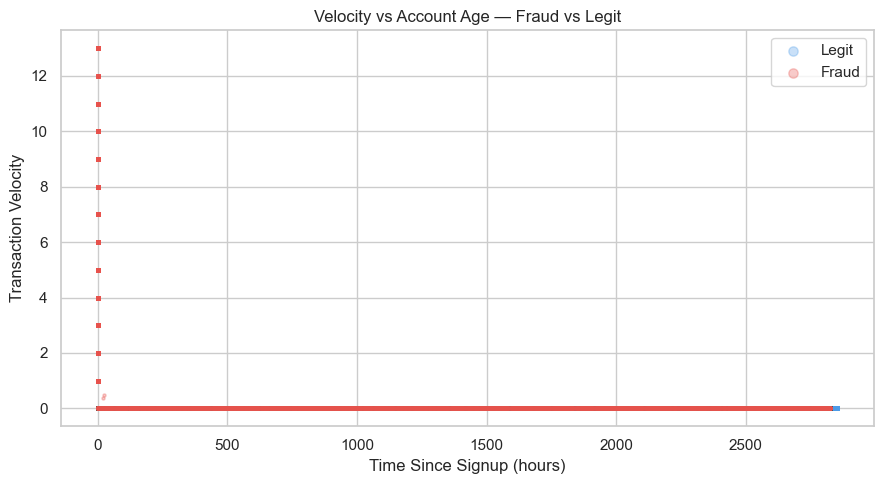

In [17]:
# Scatter: transaction_velocity vs time_since_signup_hours colored by class
fig, ax = plt.subplots(figsize=(9, 5))
for label, color, name in zip([0, 1], [BLUE, RED], ['Legit', 'Fraud']):
    subset = df[df['class'] == label]
    ax.scatter(
        subset['time_since_signup_hours'].clip(upper=subset['time_since_signup_hours'].quantile(0.99)),
        subset['transaction_velocity'].clip(upper=subset['transaction_velocity'].quantile(0.99)),
        c=color, alpha=0.3, s=5, label=name
    )
ax.set_xlabel('Time Since Signup (hours)')
ax.set_ylabel('Transaction Velocity')
ax.set_title('Velocity vs Account Age — Fraud vs Legit')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## Feature Importance Summary

In [18]:
# Point-biserial correlation of each engineered feature with the fraud class
# (equivalent to Pearson correlation for binary target)
engineered_cols = [
    'hour_of_day', 'day_of_week',
    'time_since_signup_hours',
    'transaction_count_1h', 'transaction_count_24h',
    'transaction_velocity'
]

correlations = []
for col in engineered_cols:
    r, p = stats.pointbiserialr(df['class'], df[col].fillna(0))
    correlations.append({'feature': col, 'correlation': round(r, 4), 'p_value': round(p, 6)})

corr_df = pd.DataFrame(correlations).sort_values('correlation', key=abs, ascending=False)
print('Point-biserial correlation with fraud class:')
print(corr_df.to_string(index=False))

Point-biserial correlation with fraud class:
                feature  correlation  p_value
   transaction_velocity       0.5738   0.0000
   transaction_count_1h       0.5738   0.0000
  transaction_count_24h       0.5731   0.0000
time_since_signup_hours      -0.2579   0.0000
            day_of_week       0.0189   0.0000
            hour_of_day       0.0020   0.4473


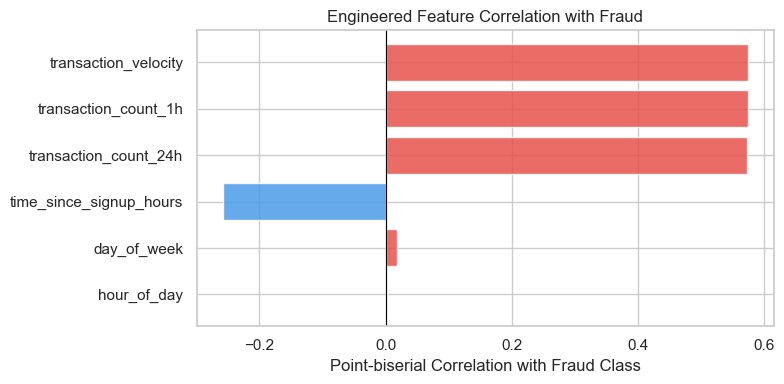

In [19]:
# Visual ranking of engineered features by correlation strength
fig, ax = plt.subplots(figsize=(8, 4))
colors = [RED if c > 0 else BLUE for c in corr_df['correlation']]
ax.barh(corr_df['feature'][::-1], corr_df['correlation'][::-1],
        color=colors[::-1], alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial Correlation with Fraud Class')
ax.set_title('Engineered Feature Correlation with Fraud')
plt.tight_layout()
plt.show()

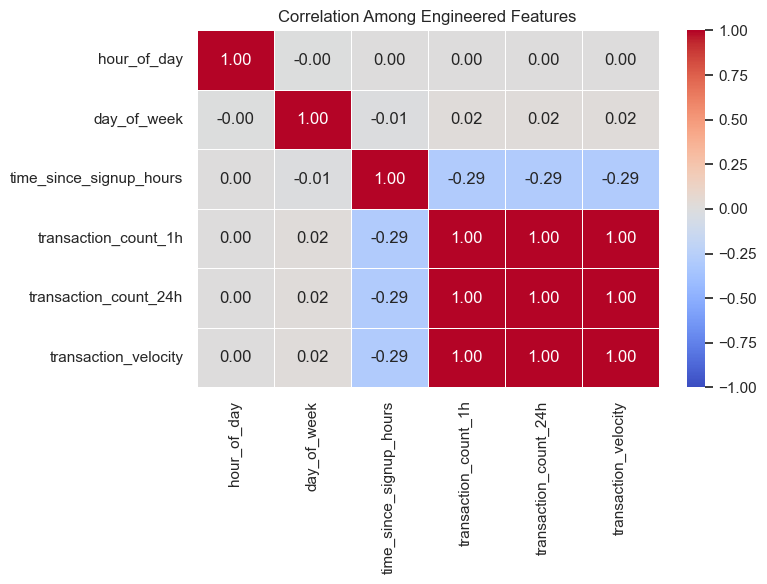

In [20]:
# Correlation matrix among engineered features
# Check for multicollinearity between new features
fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[engineered_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Among Engineered Features')
plt.tight_layout()
plt.show()

## Summary Table

In [21]:
# Build a complete feature summary table
summary_rows = []
for col in engineered_cols:
    fraud_mean = df[df['class'] == 1][col].mean()
    legit_mean = df[df['class'] == 0][col].mean()
    r, p       = stats.pointbiserialr(df['class'], df[col].fillna(0))
    summary_rows.append({
        'feature':        col,
        'fraud_mean':     round(fraud_mean, 4),
        'legit_mean':     round(legit_mean, 4),
        'correlation':    round(r, 4),
        'p_value':        round(p, 6),
        'significant':    'Yes' if p < 0.05 else 'No'
    })

summary_df = pd.DataFrame(summary_rows).sort_values('correlation', key=abs, ascending=False)
print('Complete Engineered Feature Summary:')
print(summary_df.to_string(index=False))

Complete Engineered Feature Summary:
                feature  fraud_mean  legit_mean  correlation  p_value significant
   transaction_velocity      2.6803      0.0000       0.5738   0.0000         Yes
   transaction_count_1h      2.6811      0.0000       0.5738   0.0000         Yes
  transaction_count_24h      2.6833      0.0008       0.5731   0.0000         Yes
time_since_signup_hours    673.2896   1441.9941      -0.2579   0.0000         Yes
            day_of_week      3.1300      2.9996       0.0189   0.0000         Yes
            hour_of_day     11.5636     11.5172       0.0020   0.4473          No
